<h1><center>Laboratorio 4: EDA en Pandas 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Jiale Chen
- Nombre de alumno 2:


### **Link de repositorio de GitHub:** `http://....`


## Reglas:

- **Grupos de 2 personas**
- Asistencia **obligatoria** a instrucciones del lab (viernes 16.15). Luego, pueden quedarse trabajando en las salas o irse.
- **No se revisarán entregas de personas ausentes**. 
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias. 
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Aplicar los paradigmas y buenas prácticas de programación vistas hasta este momento.
- Utilizar las funciones de la librería `pandas` para realizar análisis exploratorio de datos
- Aplicar principios de visualización de datos vistos en clases para mostrar patrones en los datos


El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas de `pandas`.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [85]:
# Libreria Core del lab.

# Libreria para plotear
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import Markdown, display
from scipy import stats

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar dataset [0.5 puntos]

Mr. Lepin Mora quien es el gerente de una cotizada tienda de retail en Europa, les solicita si pueden analizar los datos de algunas de sus tiendas.

Para esto, el área de ventas les entrega el 2 archivos: `online_retail_II.pickle` y `online_retail_I.pickle`.
- Cargue ambas fuentes y asegúrese que las columnas son del tipo correcto como en el ejemplo de df_retail_1 visualizando los datos para determinar el tipo. Para fechas, puede usar `'datetime64[ns]'`
- Combine los dataframes en uno solo. ¿Qué función debe utilizar en este caso?
- Señale las columnas que componen el dataset combinado, el tipo de variable presente en cada columna y comente que representa cada una de estas.

**Respuesta:**

2- Se utiliza `merge` porque ambos datasets comparten la clave `Invoice` y contienen información complementaria, lo que permite agregar la fecha de la factura (`InvoiceDate`) a cada registro de ventas. Se emplea `how="left"` para conservar todos los registros de `df_retail_1`, incluso aquellos que no tengan una fecha asociada en `df_retail_2`, evitando así pérdida de información.

3- El dataset combinado está compuesto por las variables `Invoice`, `StockCode`, `Description`, `Quantity`, `Price`, `Customer ID`, `Country` e `InvoiceDate`, las cuales provienen de la unión de dos fuentes de datos mediante la clave `Invoice`.

`Invoice` es una variable categórica que identifica cada factura de compra; una misma factura puede contener múltiples productos, por lo que este campo se repite por cada ítem de la transacción. `StockCode` es una variable categórica que identifica cada producto, mientras que `Description` es una variable de tipo texto (string) que describe el artículo vendido.

`Quantity` es una variable numérica discreta (`int64`) que representa la cantidad de unidades vendidas por producto, y `Price` es una variable numérica continua (`float64`) que indica el precio unitario del artículo. `Customer ID` es un identificador categórico del cliente, utilizado para analizar el comportamiento de compra a nivel individual, y `Country` es una variable categórica que indica el país de la transacción.

Finalmente, `InvoiceDate` es una variable de tipo temporal (`datetime64[ns]`) que proviene del segundo dataset y representa la fecha y hora exacta de la factura.

En conjunto, el dataset resultante corresponde a ventas a nivel de ítem dentro de cada factura, permitiendo el análisis de clientes, productos, distribución geográfica y evolución temporal de las ventas.

In [86]:
df_retail_1 = pd.read_pickle("online_retail_I.pickle")
df_retail_1 = df_retail_1.astype(
    {
        "Invoice": "category",
        "StockCode": "category",
        "Description": str,
        "Quantity": int,
        "Price": float,
        "Customer ID": "category",
        "Country": object,
    }
)
df_retail_1.head(10)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,3.75,13085.0,United Kingdom


In [87]:
df_retail_2 = pd.read_pickle("online_retail_II.pickle")
# Resto de su código
df_retail_2 = df_retail_2.astype(
    {
        "Invoice": "category",
        "InvoiceDate": "datetime64[ns]",
    }
)

df_retail_2.head(10)

,Invoice,InvoiceDate
0,489434,2009-12-01 07:45:00
1,489435,2009-12-01 07:46:00
2,489436,2009-12-01 09:06:00
3,489437,2009-12-01 09:08:00
4,489438,2009-12-01 09:24:00
5,489439,2009-12-01 09:28:00
6,489440,2009-12-01 09:43:00
7,489441,2009-12-01 09:44:00
8,489442,2009-12-01 09:46:00
9,489443,2009-12-01 09:50:00


In [88]:
df_retail = pd.merge(df_retail_1, df_retail_2, on="Invoice", how="left")
print(df_retail.columns)
df_retail.head()

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'Price',
       'Customer ID', 'Country', 'InvoiceDate'],
      dtype='str')


,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,2009-12-01 07:45:00


## 1.2 Análisis Explotatorio de los Datos [0.5 puntos] 

En base a la primera visualización del dataset, *Don Mora* le solicita que realicen un análisis exploratorio de los datos, para esto les deberán realizar un análisis univariado y multivariado. De la revisión, ustedes deben explicar potenciales anomalías visualizadas y señalar si existe la necesidad de realizar una limpieza de datos.

Explique a que nos referimos con análisis univariable, multivariable y de datos faltantes. ¿Qué beneficios nos otorga estudiar estos datos?. Sea conciso con su respuesta y no escriba mas de 5 líneas para su respuesta.

**Respuesta a la Pregunta:**

> Respuesta Aquí

El análisis univariable estudia cada variable por separado para entender su distribución, tendencia central y valores atípicos. El análisis multivariable analiza relaciones entre variables para identificar patrones o correlaciones. El análisis de datos faltantes detecta y clasifica valores ausentes, considerando mecanismos como MCAR, MAR y MNAR. Estos análisis permiten identificar anomalías y mejorar la calidad de los datos. Su principal beneficio es asegurar una base confiable para el análisis y la toma de decisiones.

### 1.2.1 Análisis Univariado [1.5 Puntos]

A continuación, se le presentan dos funciones para analizar los datos que componen un dataframe. La primera de estas es la función ``profile_serie()`` la cual recibe una serie y le entrega un análisis detallado de los datos que conforman dicha serie. 

Ejecute la funcion ``profile_serie()`` sobre cada serie para realizar un análisis univariado de estas. A continuación, comente acerca de el comportamiento de cada variable según las estadísticas descriptivas y los gráficos generados.

In [89]:
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype, is_timedelta64_dtype


def profile_serie(serie_in, n_samples=1000, random_state=42):
    serie = serie_in.copy()

    profile = pd.Series(dtype="object")
    profile["Type"] = serie.dtype
    profile = pd.concat([profile, serie.describe()])

    # profile = pd.Series([])

    if is_numeric_dtype(serie):
        profile["Negative"] = (serie < 0).sum()
        profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Zeros"] = (serie == 0).sum()
        profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Kurt"] = serie.kurt()
        profile["Skew"] = serie.skew()

    profile[" "] = " "  # espacio

    profile["Missing cells"] = serie.isnull().sum()
    profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
    profile["Duplicate rows"] = serie.duplicated(False).sum()
    profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
    profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

    # profile = pd.concat([profile, description])

    profile = profile.rename(
        index={
            "count": "Number of observations",
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "max": "Max",
            "unique": "Unique",
            "top": "Top",
            "freq": "Freq",
        }
    )
    no_outliers_fig = None

    if is_numeric_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name} - With Outliers")

        no_outliers = sampled_serie.loc[(np.abs(stats.zscore(sampled_serie)) < 3)]
        # zscore = https://es.wikipedia.org/wiki/Unidad_tipificada

        no_outliers_fig = px.histogram(no_outliers, marginal="box", title=f"{serie.name} - Without Outliers")

    elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

    else:
        count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
        fig = px.bar(
            x=count[serie.name].astype(str),
            y=count["Count"],
            title=f"100 Most common categories of {serie.name}",
        )
    display(Markdown(f"## {serie.name} Profile"))
    display(profile)
    fig.show()

    if no_outliers_fig:
        no_outliers_fig.show()

    # return fig, profile

In [90]:
profile_serie(df_retail["Price"])

## Price Profile

Type                            float64
Number of observations         525461.0
Mean                           4.688834
Std                          146.126914
Min                           -53594.36
25%                                1.25
50%                                 2.1
75%                                4.21
Max                            25111.09
Negative                              3
Negative (%)                      0.0 %
Zeros                              3687
Zeros (%)                         0.7 %
Kurt                       64868.344873
Skew                        -140.768446
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   524485
Duplicate rows (%)              99.81 %
Total size in memory      4203820 bytes
dtype: object

    Análisis de la primera serie

La variable **Price** presenta una distribución altamente sesgada y dominada por valores atípicos. El skewness negativo extremo (−140.77) y la alta curtosis (64.868) evidencian colas pesadas, influenciadas por valores mínimos anómalos como −53.594. Sin embargo, visualmente la mayoría de los datos se concentra en valores bajos, por lo que estos estadísticos no representan el comportamiento típico.

La **mediana (2.10)** resulta más representativa que la **media (4.69)**, afectada por outliers. El rango intercuartílico (1.25–4.21) muestra que la mayoría de los precios son bajos y homogéneos, mientras que la alta desviación estándar refleja la influencia de valores extremos. Al eliminar outliers, el rango se reduce de aproximadamente −160 a 1300 hacia 0–130, permitiendo observar mejor la distribución real.

Se identifican anomalías relevantes: valores negativos (posibles errores o ajustes), y precios iguales a cero (0.7%), que podrían indicar promociones o errores de registro. No hay datos faltantes, pero dada la presencia de outliers y valores inconsistentes, es necesario realizar una limpieza de datos antes de análisis posteriores.

In [91]:
profile_serie(df_retail["Quantity"])

## Quantity Profile

Type                              int64
Number of observations         525461.0
Mean                          10.337667
Std                           107.42411
Min                             -9600.0
25%                                 1.0
50%                                 3.0
75%                                10.0
Max                             19152.0
Negative                          12326
Negative (%)                     2.35 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                        6277.666908
Skew                          36.044617
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525122
Duplicate rows (%)              99.94 %
Total size in memory      4203820 bytes
dtype: object

    Análisis de la segunda serie

La variable **Quantity** presenta una distribución fuertemente asimétrica a la derecha (skewness = 36.04) y alta curtosis (6.277), lo que evidencia una gran concentración de valores bajos y presencia de outliers extremos. Visualmente, la mayoría de las observaciones se concentra entre 0 y 5 unidades, mientras que unos pocos valores elevados distorsionan la distribución.

La **media (10.34)** es considerablemente mayor que la **mediana (3.0)**, indicando sesgo positivo. El rango intercuartílico (1–10) confirma que la mayoría de las transacciones son pequeñas, mientras que la alta desviación estándar refleja la influencia de valores extremos. Al eliminar outliers, el rango se reduce de aproximadamente −160 a 567 hacia −26 a 100, permitiendo observar mejor la estructura real de los datos.

Se identifican anomalías relevantes: un 2.35% de valores negativos, probablemente asociados a devoluciones o cancelaciones. No hay datos faltantes, pero la presencia de outliers y valores negativos sugiere la necesidad de limpieza.

In [92]:
profile_serie(df_retail["Invoice"])

## Invoice Profile

Type                           category
Number of observations           525461
Unique                            28816
Top                              537434
Freq                                675
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   517456
Duplicate rows (%)              98.48 %
Total size in memory      2338390 bytes
dtype: object

    Análisis de la tercera serie

La variable **Invoice** es un identificador categórico de facturas, con **28.816 valores únicos** en 525.461 observaciones. La alta duplicidad (98.48%) es esperada, ya que cada factura contiene múltiples productos, por lo que no representa un problema de calidad sino la estructura propia de datos transaccionales.

El gráfico de frecuencias muestra una distribución decreciente sin valores dominantes anómalos; por ejemplo, la factura más frecuente tiene 675 registros y las del extremo inferior del top 100 cerca de 256. Esto sugiere un comportamiento natural donde algunas facturas agrupan más productos, posiblemente influenciado por momentos específicos de compra reflejados en la fecha.

No existen valores faltantes en esta variable, por lo que no requiere limpieza directa; sin embargo, su uso en conjunto con otras variables puede ayudar a detectar inconsistencias, como facturas con valores negativos o registros atípicos.

In [93]:
profile_serie(df_retail["StockCode"])

## StockCode Profile

Type                           category
Number of observations           525461
Unique                             4632
Top                              85123A
Freq                               3516
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525026
Duplicate rows (%)              99.92 %
Total size in memory      1220246 bytes
dtype: object

    Análisis de la cuarta serie

La variable **StockCode** es un identificador categórico de producto, con **4.632 valores únicos** sobre 525.461 observaciones. La alta duplicidad (99.92%) es esperada, ya que un mismo producto puede aparecer en múltiples transacciones, por lo que no representa un problema de calidad.

El gráfico de frecuencias muestra una distribución tipo *long-tail*, donde el producto más frecuente (**85123A**) destaca con 3.516 registros, seguido de una caída progresiva hasta estabilizarse. Esto indica la existencia de productos muy populares junto a muchos de baja frecuencia, patrón típico en retail.

Se observan códigos no convencionales como **POST**, **M** y **DOT**. Estos registros constituyen anomalías relevantes que deben ser tratados o eliminados en una etapa de limpieza, ya que pueden distorsionar análisis de ventas y comportamiento de clientes. No hay valores faltantes en la variable.

In [94]:
profile_serie(df_retail["Description"])

## Description Profile

Type                                                     str
Number of observations                                522533
Unique                                                  4681
Top                       WHITE HANGING HEART T-LIGHT HOLDER
Freq                                                    3549
                                                            
Missing cells                                           2928
Missing cells (%)                                     0.56 %
Duplicate rows                                        525198
Duplicate rows (%)                                   99.95 %
Total size in memory                           4203820 bytes
dtype: object

    Análisis de la quinta serie

La variable **Description** posee **4.681 valores únicos**. La alta duplicidad (99.95%) es esperada, ya que un mismo producto se vende múltiples veces.

El gráfico de frecuencias muestra una distribución tipo *long-tail*, donde **WHITE HANGING HEART T-LIGHT HOLDER** es el más frecuente. Luego, las frecuencias se estabilizan, reflejando una demanda relativamente homogénea entre varios productos.

Se observan **2.928 valores faltantes (0.56%)**, lo que constituye una anomalía relevante. Estos podrían estar asociados a códigos administrativos o errores de registro, por lo que requieren tratamiento en la etapa de limpieza para evitar problemas en la interpretación y análisis de productos.

In [95]:
profile_serie(df_retail["Customer ID"])

## Customer ID Profile

Type                           category
Number of observations         417534.0
Unique                           4383.0
Top                             14911.0
Freq                             5710.0
                                       
Missing cells                    107927
Missing cells (%)               20.54 %
Duplicate rows                   525327
Duplicate rows (%)              99.97 %
Total size in memory      1086118 bytes
dtype: object

    Análisis de la sexta serie

La variable **Customer ID** posee **4.383 valores únicos**. La alta duplicidad (99.97%) es esperada, ya que un mismo cliente puede realizar múltiples compras.

El gráfico de frecuencias muestra una distribución desigual, donde algunos clientes concentran muchas transacciones (ej. **14911 y 14606**), lo que sugiere la existencia de clientes recurrentes o mayoristas.

Se observa una anomalía importante: **20.54% de valores faltantes**, lo que es significativo. Estos pueden corresponder a clientes anónimos o registros incompletos, por lo que requieren tratamiento (eliminación, imputación o análisis separado) en la etapa de limpieza.

In [96]:
profile_serie(df_retail["Country"])

## Country Profile

Type                              object
Number of observations            525461
Unique                                40
Top                       United Kingdom
Freq                              485852
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                    525461
Duplicate rows (%)               100.0 %
Total size in memory       4203820 bytes
dtype: object

In [97]:
df_retail[df_retail["Country"] == "Unspecified"]

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
61394,494860,84832,ZINC WILLIE WINKIE CANDLE STICK,5,0.85,12470.0,Unspecified,2010-01-19 11:01:00
61395,494860,84836,ZINC METAL HEART DECORATION,5,1.25,12470.0,Unspecified,2010-01-19 11:01:00
61396,494860,85014D,PINK/BROWN DOTS RUFFLED UMBRELLA,1,5.95,12470.0,Unspecified,2010-01-19 11:01:00
61397,494860,85014A,BLACK/BLUE DOTS RUFFLED UMBRELLA,1,5.95,12470.0,Unspecified,2010-01-19 11:01:00
61398,494860,85014B,RED/WHITE DOTS RUFFLED UMBRELLA,2,5.95,12470.0,Unspecified,2010-01-19 11:01:00
...,...,...,...,...,...,...,...,...
499215,536012,79000,MOROCCAN TEA GLASS,12,0.85,12351.0,Unspecified,2010-11-29 15:23:00
499216,536012,22665,RECIPE BOX BLUE SKETCHBOOK DESIGN,6,2.95,12351.0,Unspecified,2010-11-29 15:23:00
499217,536012,20886,BOX OF 9 PEBBLE CANDLES,6,1.95,12351.0,Unspecified,2010-11-29 15:23:00
499218,536012,22424,ENAMEL BREAD BIN CREAM,1,12.75,12351.0,Unspecified,2010-11-29 15:23:00


In [98]:
(df_retail[df_retail["Country"] == "Unspecified"]["Customer ID"]).value_counts().reset_index(name="frecuencia").head(10)

,Customer ID,frecuencia
0,16320.0,187
1,14265.0,48
2,12470.0,23
3,12351.0,21
4,15357.0,1
5,12346.0,0
6,12347.0,0
7,12348.0,0
8,12349.0,0
9,12352.0,0


In [99]:
ids = [16320.0, 14265.0, 12470.0, 12351.0, 15357.0]
df_retail[(df_retail["Customer ID"].isin(ids)) & (df_retail["Country"] != "Unspecified")]

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate


    Análisis de la séptima serie

La variable **Country** es categórica con **40 valores únicos** y no presenta valores faltantes. La alta duplicidad es esperada debido al límite de la cantidad de países frente al total de registros (tamaño del dataset).

El gráfico muestra una fuerte concentración en **United Kingdom**, mientras que el resto de países tiene una participación marginal. Esto evidencia un claro desbalance geográfico en los datos.

Se identifica la categoría **"Unspecified"** como una anomalía, ya que representa ubicaciones no registradas correctamente. Aunque se puede conservar estos datos, dado que la mayoría representa ventas válidas y no hay datos para rellenar ese defecto.

### 1.2.2 Análisis Multivariado y Datos Faltantes [1 ptos]

En segundo lugar encontrará la función ``profile_df()`` que recibe un dataframe como entrada y realiza un análisis bivariado de todas las variables numéricas que conforman el dataframe, un analisis de la correlación de Pearson entre las variables numericas del dataframe y la matriz de datos faltantes.

Utilice esta función en el dataframe. Comente sobre los patrones que observa. Luego responda:
- Existen correlaciones relevantes observadas?
- Qué aspectos revelan estos gráficos acerca de la limpieza de los datos?

In [100]:
def profile_df(dataframe_in):
    df = dataframe_in.copy()

    list_type = []
    for col in list(df.columns):
        if is_numeric_dtype(df[col]) or is_datetime64_any_dtype(df[col]) or is_timedelta64_dtype(df[col]):
            list_type.append(col)

    display(Markdown("## Bivariant Analysis:"))
    for i in range(len(list_type)):
        for j in range(i + 1, len(list_type)):
            plt.scatter(df[list_type[i]], df[list_type[j]])
            plt.xlabel(list_type[i])
            plt.ylabel(list_type[j])
            plt.title(f"{list_type[i]} v/s {list_type[j]}")
            plt.show()

    display(Markdown("## Correlation:"))
    fig_corr = px.imshow(df[list_type].corr())
    fig_corr.show()

    display(Markdown("## Missing Matrix:"))
    fig, ax = plt.subplots(figsize=[15, 10])
    msno.matrix(df, ax=ax, sparkline=False)

## Bivariant Analysis:

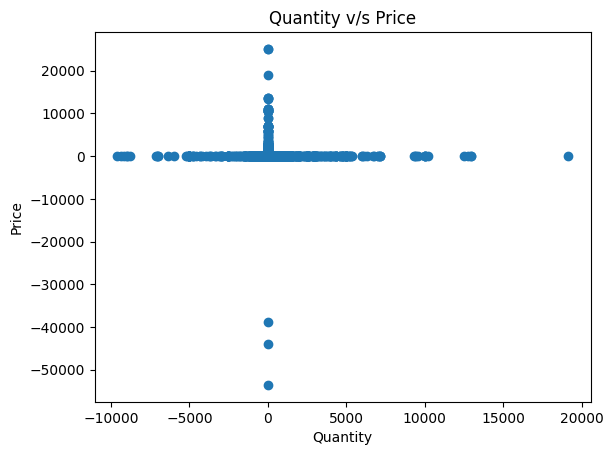

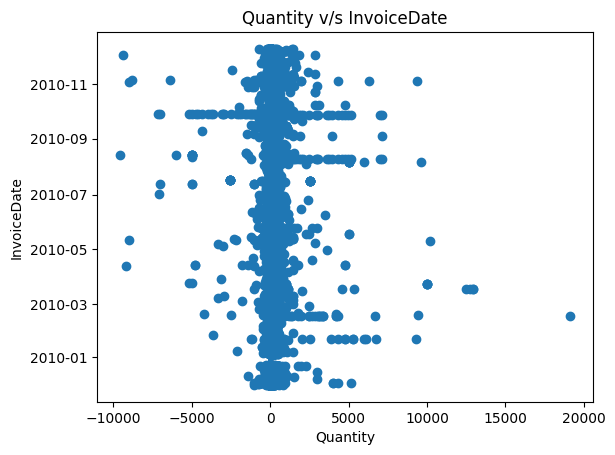

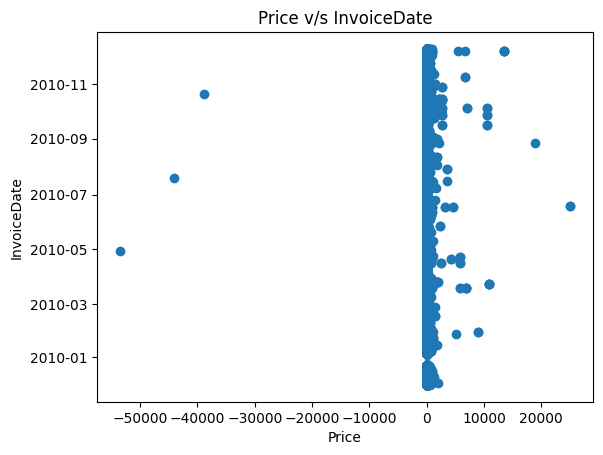

## Correlation:

## Missing Matrix:

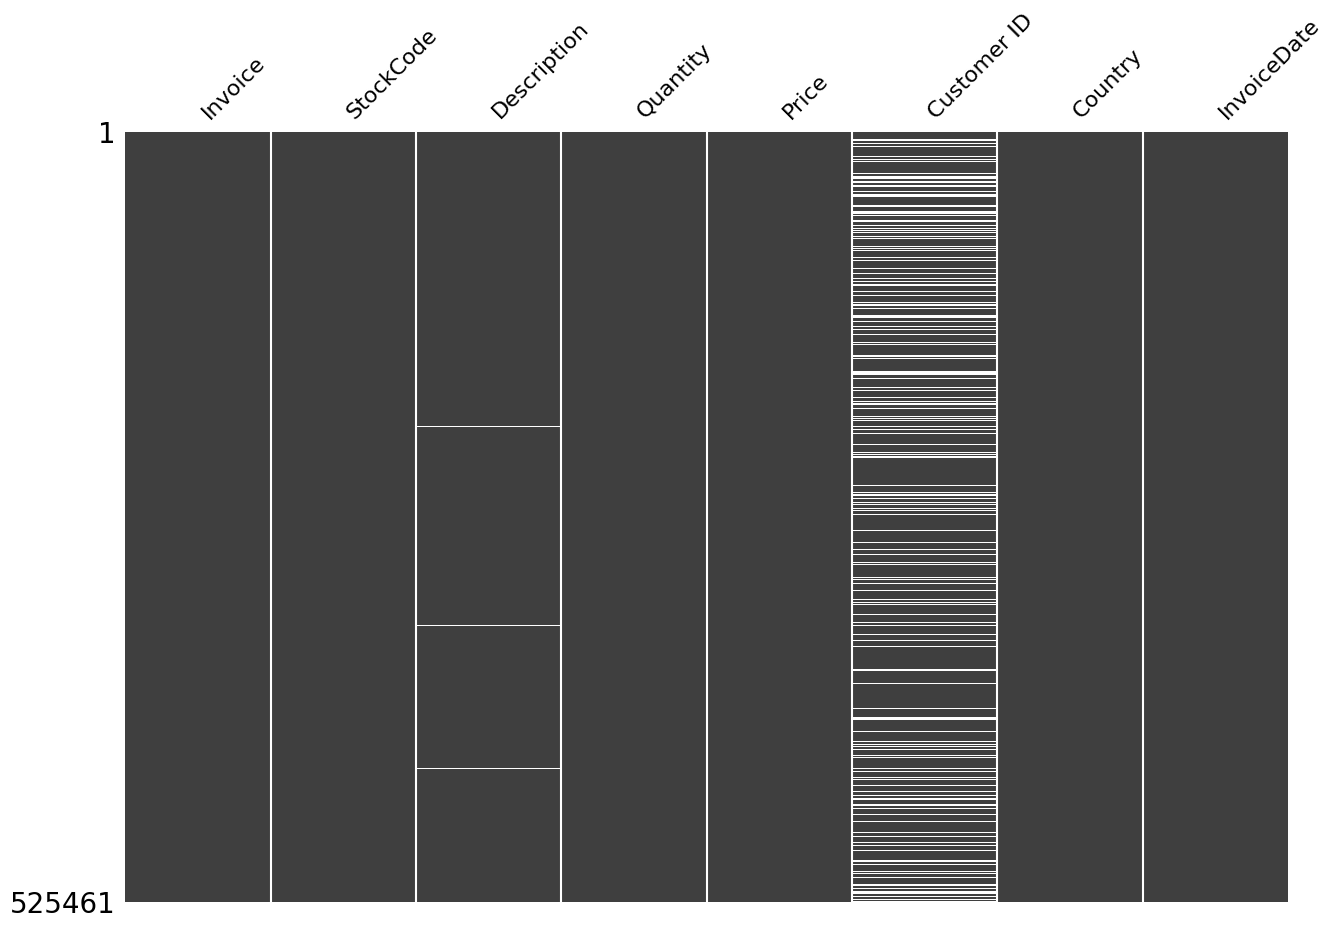

In [101]:
profile_df(df_retail)

**Respuesta**

El análisis multivariado revela que las tres variables numéricas del dataset (**Quantity**, **Price** e **InvoiceDate**) no presentan correlaciones lineales relevantes entre sí. La matriz de correlación de Pearson muestra valores cercanos a cero en todas las combinaciones cruzadas, con únicamente la diagonal principal en amarillo (correlación perfecta consigo misma). Esto indica que el precio unitario de un producto no está linealmente relacionado con la cantidad pedida, y que ninguna de estas variables presenta una tendencia temporal sistemática a lo largo del período registrado.

Los scatterplots bivariados refuerzan esta conclusión y además evidencian de forma clara los problemas de calidad presentes en los datos. En el gráfico **Quantity vs Price**, la gran mayoría de los puntos se concentra en una banda horizontal cercana a cero en ambos ejes, pero se observan valores extremos aislados que alcanzan precios de hasta 25.000 y −53.000, así como cantidades superiores a 19.000 y negativas hasta −9.600. Estos puntos no siguen ningún patrón coherente con el resto de la distribución y representan registros anómalos que deben ser tratados. En los gráficos **Quantity vs InvoiceDate** y **Price vs InvoiceDate**, se aprecia que los outliers extremos están distribuidos a lo largo de todo el período temporal sin concentrarse en fechas específicas, lo que sugiere que no corresponden a eventos puntuales sino a errores sistemáticos de registro presentes durante todo el horizonte de datos.

La matriz de datos faltantes confirma los hallazgos del análisis univariado y permite caracterizar el mecanismo de missing de cada variable afectada. **Customer ID** presenta ausencias significativas, representadas por las líneas blancas densas distribuidas a lo largo de todas las filas del dataset. Al analizar estos registros, no se identifica ningún patrón sistemático que relacione la ausencia con otras variables observables: la mayoría corresponde a transacciones con cantidades positivas y precios válidos, lo que indica un mecanismo **MCAR (Missing Completely At Random)**. La ausencia del identificador de cliente parece responder simplemente a compras realizadas sin registro de cuenta, de forma independiente a cualquier otra característica de la transacción.

**Description**, en cambio, presenta un mecanismo distinto. Sus valores faltantes, aunque menos numerosos (0.56%), están sistemáticamente asociados a registros donde el precio es 0 y el `Customer ID` también es nulo, lo que revela una dependencia estructural con otras variables observables del dataset. Esto clasifica su missing como **MAR (Missing At Random)**: la ausencia de descripción no es al azar, sino predecible a partir de la información disponible en otras columnas, correspondiendo en su mayoría a registros administrativos o transacciones inválidas sin producto físico asociado.

En síntesis, estos gráficos revelan dos aspectos críticos para la etapa de limpieza: por un lado, la presencia de **outliers extremos** en `Quantity` y `Price` que distorsionan cualquier análisis estadístico y deben ser filtrados; y por otro, la existencia de **valores faltantes con mecanismos distintos**: los de `Customer ID` son MCAR y podrían conservarse asignando una categoría especial como `"Guest"` para no perder información de venta válida, mientras que los de `Description` son MAR y su eliminación está justificada al estar asociados a registros sin valor analítico.

# Esto es un agregado para mostrar los tipos de valores perdidos

In [102]:
df_retail[df_retail["Customer ID"].isnull()]

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
263,489464,21733,85123a mixed,-96,0.00,NaN,United Kingdom,2009-12-01 10:52:00
283,489463,71477,short,-240,0.00,NaN,United Kingdom,2009-12-01 10:52:00
284,489467,85123A,21733 mixed,-192,0.00,NaN,United Kingdom,2009-12-01 10:53:00
470,489521,21646,NaN,-50,0.00,NaN,United Kingdom,2009-12-01 11:44:00
577,489525,85226C,BLUE PULL BACK RACING CAR,1,0.55,NaN,United Kingdom,2009-12-01 11:49:00
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,0.00,NaN,United Kingdom,2010-12-09 17:17:00
525232,538158,20892,NaN,-32,0.00,NaN,United Kingdom,2010-12-09 17:17:00
525233,538160,20956,NaN,288,0.00,NaN,United Kingdom,2010-12-09 17:18:00
525234,538161,46000S,Dotcom sales,-100,0.00,NaN,United Kingdom,2010-12-09 17:25:00


In [103]:
(df_retail["Customer ID"].isnull() & (df_retail["Quantity"] < 0)).sum()

np.int64(2487)

In [104]:
df_retail[df_retail["Description"].isnull()]

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
470,489521,21646,NaN,-50,0.0,NaN,United Kingdom,2009-12-01 11:44:00
3114,489655,20683,NaN,-44,0.0,NaN,United Kingdom,2009-12-01 17:26:00
3161,489659,21350,NaN,230,0.0,NaN,United Kingdom,2009-12-01 17:39:00
3731,489781,84292,NaN,17,0.0,NaN,United Kingdom,2009-12-02 11:45:00
4296,489806,18010,NaN,-770,0.0,NaN,United Kingdom,2009-12-02 12:42:00
...,...,...,...,...,...,...,...,...
524730,538141,22218,NaN,2,0.0,NaN,United Kingdom,2010-12-09 15:58:00
524731,538143,84534B,NaN,1,0.0,NaN,United Kingdom,2010-12-09 15:58:00
525231,538159,21324,NaN,-18,0.0,NaN,United Kingdom,2010-12-09 17:17:00
525232,538158,20892,NaN,-32,0.0,NaN,United Kingdom,2010-12-09 17:17:00


In [105]:
mask = (df_retail["Description"].isnull()) & (df_retail["Customer ID"].isnull()) & (df_retail["Price"] == 0)

print(f"la cantidad de fila es {mask.sum()}")

df1 = df_retail[mask]
df2 = df_retail[df_retail["Description"].isnull()]

df1.equals(df2)

la cantidad de fila es 2928


True

### 1.2.3 Limpieza de Datos [1 pto]

Como pudo ver en las secciones anteriores, los datos presentan valores erroneos, es por esto que se le solicita que realice una función que permita limpiar el dataset. Realice esta función en base observaciones propias y considere como **imposible tener cantidades negativas** en las ventas. Investigue sobre métodos para eliminar outliers usando pandas

Una vez realizada la función, realice nuevamente el análisis exploratorio y comente las principales diferencias.

**Respuesta:**

In [106]:
def clean_retail(df):
    df_clean = df.copy()

    # 1. Eliminar cantidades negativas
    df_clean = df_clean[df_clean["Quantity"] > 0]

    # 2. Eliminar precios negativos
    df_clean = df_clean[df_clean["Price"] > 0]

    # 3. Eliminar registros sin descripción (estructurales)
    df_clean = df_clean[~df_clean["Description"].isnull()]

    # 4. Reemplazar Customer ID nulos por 'Guest'
    df_clean["Customer ID"] = df_clean["Customer ID"].cat.add_categories("Guest")
    df_clean["Customer ID"] = df_clean["Customer ID"].fillna("Guest")

    # 5. Eliminar códigos no convencionales de StockCode
    codigos_no_conv = ["POST", "M", "DOT"]
    df_clean = df_clean[~df_clean["StockCode"].isin(codigos_no_conv)]

    # 6. Eliminar outliers con Z-score
    for col in ["Quantity", "Price"]:
        z_scores = np.abs(stats.zscore(df_clean[col], nan_policy="omit"))
        df_clean = df_clean[z_scores < 3]

    return df_clean

In [107]:
cleaned_retail = clean_retail(df_retail)
profile_serie(cleaned_retail["Price"])
profile_serie(cleaned_retail["Quantity"])
profile_serie(cleaned_retail["Invoice"])
profile_serie(cleaned_retail["StockCode"])
profile_serie(cleaned_retail["Description"])
profile_serie(cleaned_retail["Customer ID"])
profile_serie(cleaned_retail["Country"])

## Price Profile

Type                            float64
Number of observations         507590.0
Mean                           3.388672
Std                            3.702112
Min                               0.001
25%                                1.25
50%                                 2.1
75%                                4.21
Max                               72.45
Negative                              0
Negative (%)                      0.0 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                          28.225365
Skew                           3.887734
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   507464
Duplicate rows (%)              99.98 %
Total size in memory      8121440 bytes
dtype: object

## Quantity Profile

Type                              int64
Number of observations         507590.0
Mean                           8.990932
Std                           18.379496
Min                                 1.0
25%                                 1.0
50%                                 3.0
75%                                10.0
Max                               271.0
Negative                              0
Negative (%)                      0.0 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                          55.211179
Skew                            6.38472
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   507554
Duplicate rows (%)              99.99 %
Total size in memory      8121440 bytes
dtype: object

## Invoice Profile

...

Type                                                     str
Number of observations                                507590
Unique                                                  4520
Top                       WHITE HANGING HEART T-LIGHT HOLDER
Freq                                                    3431
                                                            
Missing cells                                              0
Missing cells (%)                                      0.0 %
Duplicate rows                                        507408
Duplicate rows (%)                                   99.96 %
Total size in memory                           8121440 bytes
dtype: object

## Customer ID Profile

Type                           category
Number of observations           507590
Unique                             4273
Top                               Guest
Freq                             102924
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   507515
Duplicate rows (%)              99.99 %
Total size in memory      5243108 bytes
dtype: object

## Country Profile

Type                              object
Number of observations            507590
Unique                                40
Top                       United Kingdom
Freq                              470664
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                    507590
Duplicate rows (%)               100.0 %
Total size in memory       8121440 bytes
dtype: object

## Bivariant Analysis:

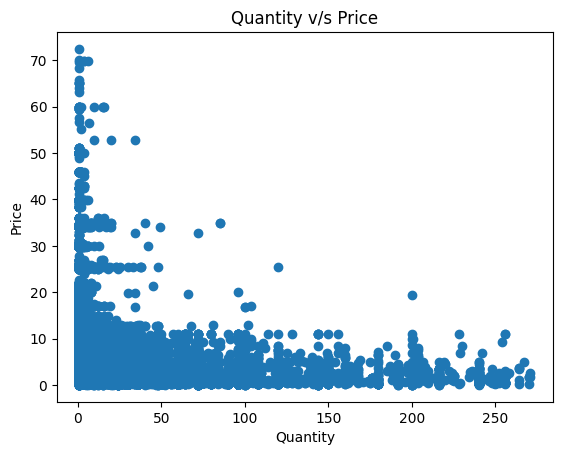

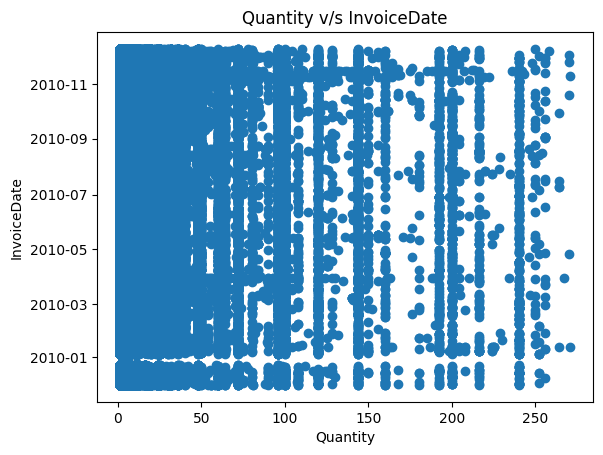

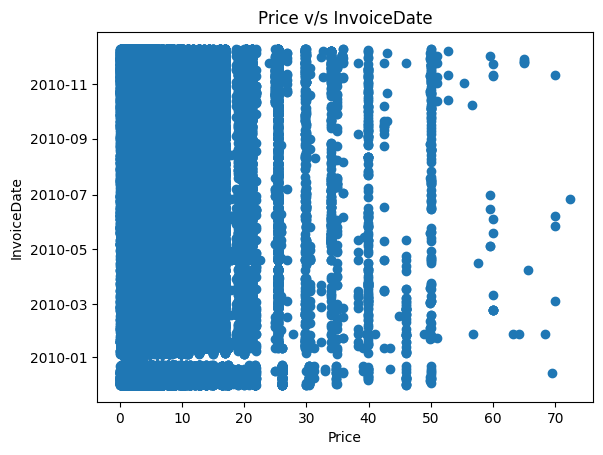

## Correlation:

## Missing Matrix:

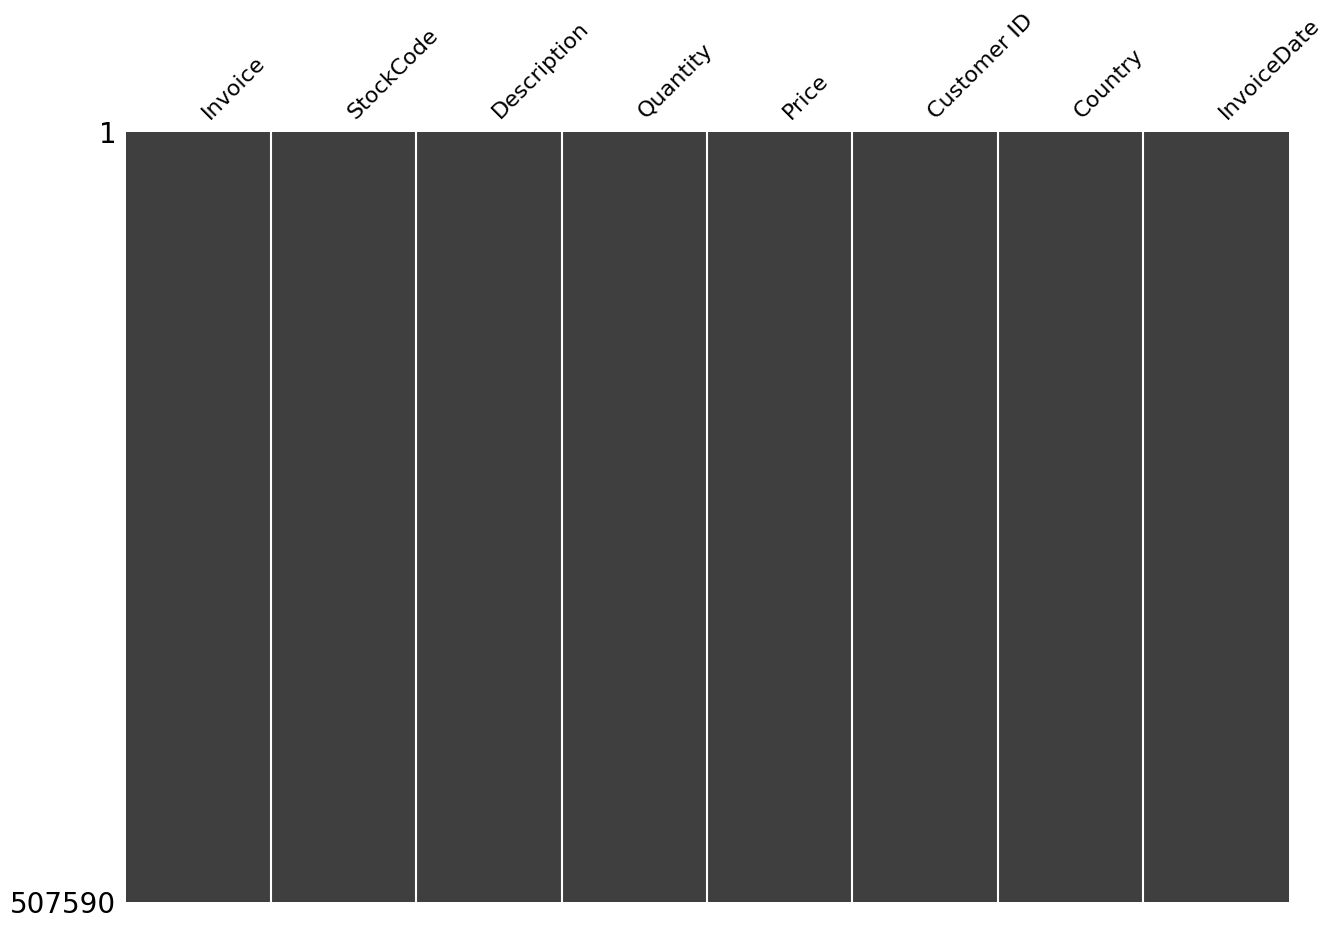

In [108]:
profile_df(cleaned_retail)

**Respuesta:**

Después de realizar la limpieza y el ajuste de los datos, se observa una mejora significativa en la calidad del dataset. En particular, las variables numéricas presentan una menor presencia de outliers, y la variable `Price` ya no contiene valores negativos, lo que la hace consistente con el contexto de ventas reales. Asimismo, las distribuciones de los datos resultan más coherentes y representativas.

En el caso de `Customer ID`, los valores faltantes (`NaN`) que correspondían a transacciones válidas fueron reemplazados por la categoría `Guest`. Esto permite identificar que una proporción importante de las compras fue realizada por clientes no registrados, siendo `Guest` la categoría dominante muy por encima del resto de clientes.

La matriz de correlación confirma que, incluso tras la limpieza, no existen correlaciones lineales relevantes entre `Quantity`, `Price` e `InvoiceDate`, lo cual es esperado en datos de ventas donde el precio y la cantidad son independientes por producto.

Por otra parte, se eliminaron registros con códigos especiales en `StockCode` como `POST`, `M` y `DOT`, los cuales no representan productos reales. Como resultado, estos valores dejan de aparecer en los gráficos, mejorando la interpretación y coherencia de los análisis.

Finalmente, al eliminar registros con descripciones inválidas y valores atípicos extremos, se mejora la integridad del dataset. Como resultado, la matriz de valores faltantes se presenta completamente limpia, sin anomalías visibles.

### 1.2.4 Obtención de TOPs [0.75 ptos]

Sin considerar los comentarios realizados en la sección 1.2 , *Don Mora* les pide obtener el **Top de 30 productos que generan más ganancias** para la tienda de retail. Deben considerar todo el registro temporal presente en el dataset y entregar la información en un gráfico de barras de los ingresos/cantidades v/s el nombre de los productos (Utilice `plotly`). ¿Los artículos más vendidos son los mismos que generan más ganancias?, Comente los resultados obtenidos.

**Resultados:**

In [109]:
def top_30_productos(df):
    df = df.copy()

    # Crear variable de ingresos
    df["Revenue"] = df["Quantity"] * df["Price"]

    # Top 30 por ingresos
    top_products = (
        df.groupby("Description", as_index=False)
        .agg({"Revenue": "sum", "Quantity": "sum"})
        .sort_values("Revenue", ascending=False)
        .head(30)
    )

    # Gráfico 1: Description vs Revenue
    fig1 = px.bar(
        top_products, x="Description", y="Revenue", title="Top 30 productos por ingresos", hover_data=["Quantity"]
    )

    fig1.update_layout(xaxis_tickangle=-45)
    fig1.show()

    # Top 30 por cantidad
    top_quantity = (
        df.groupby("Description", as_index=False)
        .agg({"Quantity": "sum"})
        .sort_values("Quantity", ascending=False)
        .head(30)
    )

    # Gráfico 2: Description vs Quantity
    fig2 = px.bar(top_quantity, x="Description", y="Quantity", title="Top 30 productos por cantidad vendida")

    fig2.update_layout(xaxis_tickangle=-45)
    fig2.show()

    # Intersección
    interseccion = set(top_products["Description"]) & set(top_quantity["Description"])

    return top_products, top_quantity, interseccion

In [110]:
top_rev, top_qty, inter = top_30_productos(df_retail)

len(inter), inter

(6,
 {'ASSORTED COLOUR BIRD ORNAMENT',
  'JUMBO BAG RED RETROSPOT',
  'JUMBO BAG STRAWBERRY',
  'LUNCH BAG RED SPOTTY',
  'STRAWBERRY CERAMIC TRINKET BOX',
  'WHITE HANGING HEART T-LIGHT HOLDER'})

Los resultados muestran que los productos que generan mayores ingresos no coinciden 
necesariamente con los más vendidos en cantidad. Solo 6 productos aparecen en ambos 
rankings: `WHITE HANGING HEART T-LIGHT HOLDER`, `JUMBO BAG RED RETROSPOT`, 
`ASSORTED COLOUR BIRD ORNAMENT`, entre otros. 

Productos como `REGENCY CAKESTAND 3 TIER` lideran en ingresos sin aparecer 
entre los más vendidos, lo que sugiere un precio unitario elevado. En contraste, 
artículos como `WORLD WAR 2 GLIDERS ASSTD DESIGNS` destacan en volumen pero 
contribuyen poco al ingreso total debido a su bajo precio unitario.

Esto evidencia que el ingreso está determinado tanto por la cantidad como por el precio, 
por lo que centrarse únicamente en volumen de ventas puede llevar a conclusiones 
incompletas. Para la toma de decisiones comerciales es clave considerar métricas de 
rentabilidad además de popularidad.

### 1.2.5 Visualización del registro temporal [0,75 ptos]

El dueño del retail en su afán por saber más sobre los datos de su firma les solicita que grafiquen las ventas respecto al tiempo. Con esto les aclara que durante el día tienen muchas variaciones en sus ventas, por lo que les recomienda que consideren el registro temporal como `año-mes-día`. ¿Es posible observar datos extraños?, Comente lo que observa del gráfico.

In [111]:
def plot_ventas(dataframe):
    df = dataframe.copy()

    # Asegurar formato datetime
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

    # Crear columnas temporales
    df["Date"] = df["InvoiceDate"].dt.date
    df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)
    df["Year"] = df["InvoiceDate"].dt.year

    # Calcular ingresos
    df["Revenue"] = df["Quantity"] * df["Price"]

    # Ventas por día
    daily_sales = df.groupby("Date", as_index=False).agg({"Revenue": "sum"}).sort_values("Date")

    fig_day = px.line(daily_sales, x="Date", y="Revenue", title="Ventas diarias")
    fig_day.show()

    # Ventas por mes
    monthly_sales = df.groupby("YearMonth", as_index=False).agg({"Revenue": "sum"}).sort_values("YearMonth")

    fig_month = px.line(monthly_sales, x="YearMonth", y="Revenue", title="Ventas mensuales")
    fig_month.show()

    # Ventas por año
    yearly_sales = df.groupby("Year", as_index=False).agg({"Revenue": "sum"}).sort_values("Year")

    fig_year = px.line(yearly_sales, x="Year", y="Revenue", title="Ventas anuales")
    fig_year.show()

    return daily_sales, monthly_sales, yearly_sales

In [112]:
plot_ventas(df_retail)

(           Date   Revenue
 0    2009-12-01  53173.03
 1    2009-12-02  62763.59
 2    2009-12-03  68093.05
 3    2009-12-04  40346.40
 4    2009-12-05   9803.05
 ..          ...       ...
 302  2010-12-05  31383.95
 303  2010-12-06  53860.18
 304  2010-12-07  45059.05
 305  2010-12-08  44189.84
 306  2010-12-09  52532.13
 
 [307 rows x 2 columns],
    YearMonth      Revenue
 0    2009-12   799847.110
 1    2010-01   624032.892
 2    2010-02   533091.426
 3    2010-03   765848.761
 4    2010-04   590580.432
 5    2010-05   615322.830
 6    2010-06   679786.610
 7    2010-07   575236.360
 8    2010-08   656776.340
 9    2010-09   853650.431
 10   2010-10  1045168.350
 11   2010-11  1422654.642
 12   2010-12   377488.450,
    Year      Revenue
 0  2009   799847.110
 1  2010  8739637.524)

In [113]:
plot_ventas(cleaned_retail)

(           Date   Revenue
 0    2009-12-01  50829.86
 1    2009-12-02  56458.87
 2    2009-12-03  45760.18
 3    2009-12-04  38035.59
 4    2009-12-05   9803.05
 ..          ...       ...
 302  2010-12-05  30593.23
 303  2010-12-06  49257.00
 304  2010-12-07  58638.22
 305  2010-12-08  43257.12
 306  2010-12-09  45269.89
 
 [307 rows x 2 columns],
    YearMonth      Revenue
 0    2009-12   729072.250
 1    2010-01   534519.232
 2    2010-02   494013.636
 3    2010-03   692356.081
 4    2010-04   614780.432
 5    2010-05   596235.170
 6    2010-06   635477.750
 7    2010-07   573053.620
 8    2010-08   606130.900
 9    2010-09   770123.911
 10   2010-10   997703.820
 11   2010-11  1295600.922
 12   2010-12   368682.520,
    Year      Revenue
 0  2009   729072.250
 1  2010  8178677.994)

**Respuesta**

En las **ventas diarias**, ambas versiones (antes de la limpieza y después de la limpieza) presentan oscilaciones drásticas día a día a lo largo de todo el período, con subidas y bajadas abruptas que se repiten de forma consistente. Este comportamiento es esperable en un retail con alta variabilidad diaria, tal como menciona el dueño del negocio. Sin embargo, antes de la limpieza la serie presenta adicionalmente valores que caen por debajo de cero en al menos dos ocasiones (mayo y julio de 2010), lo que constituye un dato claramente anómalo que no puede explicarse por variabilidad natural del negocio. Tras la limpieza, estas caídas negativas desaparecen y la serie se mantiene estrictamente por encima de cero en todo momento, preservando las oscilaciones propias del negocio pero eliminando los registros erróneos que distorsionaban la señal. Hacia el último trimestre del año se observa en ambos casos un aumento en la magnitud de los picos diarios.

En las **ventas mensuales**, la agregación mensual suaviza las oscilaciones diarias y permite ver con mayor claridad la forma estructural de la serie: una caída desde diciembre de 2009 hasta febrero de 2010, una recuperación parcial en marzo, una meseta relativamente estable entre abril y julio, y luego un crecimiento acelerado y sostenido desde agosto hasta noviembre, seguido de una caída abrupta en diciembre que se explica por el registro incompleto del último mes del dataset. Ambas versiones comparten esta misma morfología, diferenciándose únicamente en magnitud, siendo la curva del dataset limpio ligeramente más baja.

En las **ventas anuales**, la forma es prácticamente idéntica en ambos casos: una línea recta con pendiente positiva constante entre 2009 y 2010, lo que sugiere un crecimiento lineal sostenido del negocio durante el período analizado. A esta escala de agregación, el efecto de la limpieza es imperceptible en la forma de la curva, confirmando que los registros eliminados introducían ruido a nivel granular sin alterar la tendencia estructural del negocio. Sin embargo, esta comparación debe interpretarse con cautela, ya que el año 2009 solo cuenta con datos de diciembre, por lo que la diferencia de magnitud entre ambos años responde principalmente a la cobertura temporal del dataset y no necesariamente a un crecimiento real del negocio.

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>